# ✈️ Flight Price Analysis

## Overview

This dataset contains information about domestic flight bookings in India, collected in 2019.
It is designed to support analysis and prediction of flight ticket prices based on various
factors such as airline, route, travel duration, number of stops, and journey date.

- **Total Records:** 10,683
- **Total Features:** 11
- **Target Variable:** `Price` (ticket fare in INR)
- **Missing Values:** 1 missing value each in `Route` and `Total_Stops`

---

## Column Reference

| # | Column Name       | Data Type | Description                                                                 | Unique Values / Range              |
|---|-------------------|-----------|-----------------------------------------------------------------------------|------------------------------------|
| 1 | `Airline`         | String    | Name of the airline operating the flight                                    | 12 airlines (e.g., IndiGo, Air India, Jet Airways, SpiceJet) |
| 2 | `Date_of_Journey` | String    | Date of the flight journey (format: DD/MM/YYYY)                             | 44 unique dates                    |
| 3 | `Source`          | String    | Departure city of the flight                                                | Banglore, Kolkata, Delhi, Chennai, Mumbai |
| 4 | `Destination`     | String    | Arrival city of the flight                                                  | New Delhi, Banglore, Cochin, Kolkata, Delhi, Hyderabad |
| 5 | `Route`           | String    | Full route path taken by the flight (with stopovers)                        | 128 unique routes; 1 missing value |
| 6 | `Dep_Time`        | String    | Scheduled departure time of the flight (HH:MM format)                      | 222 unique times                   |
| 7 | `Arrival_Time`    | String    | Scheduled arrival time at the destination (HH:MM format)                   | 1,343 unique times                 |
| 8 | `Duration`        | String    | Total travel duration of the flight (e.g., "2h 50m")                       | 368 unique durations               |
| 9 | `Total_Stops`     | String    | Number of stops between source and destination                              | non-stop, 1 stop, 2 stops, 3 stops, 4 stops; 1 missing value |
|10 | `Additional_Info` | String    | Extra information about the flight (meals, baggage, layovers, class, etc.)  | 10 categories (e.g., No info, Business class, Red-eye flight) |
|11 | `Price`           | Integer   | **Target variable** — Ticket price in Indian Rupees (INR)                  | Min: ₹1,759 \| Max: ₹79,512 \| Mean: ₹9,087 |

---

## Key Statistics — Price (Target Variable)

| Statistic        | Value       |
|------------------|-------------|
| Count            | 10,683      |
| Mean             | ₹9,087      |
| Std Deviation    | ₹4,611      |
| Minimum          | ₹1,759      |
| 25th Percentile  | ₹5,277      |
| Median (50th)    | ₹8,372      |
| 75th Percentile  | ₹12,373     |
| Maximum          | ₹79,512     |

---

## Notes

- **Source cities** represent 5 major Indian metros; **Destination cities** include 6 locations.
- The `Duration` and `Dep_Time`/`Arrival_Time` columns are stored as strings and may require
  parsing for time-based feature engineering.
- `Date_of_Journey` spans 44 unique dates in 2019 and can be decomposed into day, month,
  and weekday features.
- `Additional_Info` contains cabin class and service details useful for segmentation analysis.

# 1. Overall Data Analysis

In [ ]:
'''
KPI's
1) Average Ticket Price by Airline
2) Average Ticket Price by Route (Source → Destination)
3) Average Price by Number of Stops
4) Flight Volume by Airline
5) Flight Volume by Source Airport
6) Monthly Price Trend
7) Average Departure Hour by Airline
8) Average Flight Duration by Airline

'''

"\nKPI's\n1) Average Ticket Price by Airline\n2) Average Ticket Price by Route (Source → Destination)\n3) Average Price by Number of Stops\n4) Flight Volume by Airline\n5) Flight Volume by Source Airport\n6) Monthly Price Trend\n7) Average Departure Hour by Airline\n8) Average Flight Duration by Airline\n\n"

## 1.1)Importing Libraries

In [ ]:
import pandas as pd

In [ ]:
!git clone 'https://github.com/HarshvardhanSingh-13/Datasets'

Cloning into 'Datasets'...
remote: Enumerating objects: 347, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 347 (delta 25), reused 0 (delta 0), pack-reused 242 (from 1)
Receiving objects: 100% (347/347), 302.89 MiB | 15.33 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (245/245), done.


In [ ]:
pd.read_excel('/content/Datasets/Flight Prices/flight_price.xlsx')

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


#1.2) Reading the Dataset

In [ ]:
df = pd.read_excel('/content/Datasets/Flight Prices/flight_price.xlsx')

In [ ]:
# This function is used to get the top cells in the file
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [ ]:
# This function is used to get the bottom cells in the file
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [ ]:
df['Airline'] == 'IndiGo'
# here it only gives boolean value so to get the value look at the below code

,Airline
0,True
1,False
2,False
3,True
4,True
...,...
10678,False
10679,False
10680,False
10681,False


In [ ]:
df[df['Airline'] == 'IndiGo']

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
11,IndiGo,18/04/2019,Kolkata,Banglore,CCU → BLR,20:20,22:55,2h 35m,non-stop,No info,4174
14,IndiGo,24/04/2019,Kolkata,Banglore,CCU → BLR,17:15,19:50,2h 35m,non-stop,No info,4804
...,...,...,...,...,...,...,...,...,...,...,...
10631,IndiGo,15/05/2019,Delhi,Cochin,DEL → BLR → COK,02:00,07:45,5h 45m,1 stop,No info,6037
10641,IndiGo,6/03/2019,Chennai,Kolkata,MAA → CCU,07:55,10:15,2h 20m,non-stop,No info,7295
10649,IndiGo,1/03/2019,Kolkata,Banglore,CCU → BLR,21:25,00:05 02 Mar,2h 40m,non-stop,No info,4778
10664,IndiGo,9/04/2019,Banglore,Delhi,BLR → DEL,18:55,21:50,2h 55m,non-stop,No info,4823


In [ ]:
df[(df['Source'] == 'Banglore') & (df['Total_Stops'] == 'non-stop')]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
22,IndiGo,3/04/2019,Banglore,Delhi,BLR → DEL,04:00,06:50,2h 50m,non-stop,No info,3943
23,IndiGo,1/05/2019,Banglore,Delhi,BLR → DEL,18:55,21:50,2h 55m,non-stop,No info,4823
28,Vistara,18/06/2019,Banglore,Delhi,BLR → DEL,09:45,12:35,2h 50m,non-stop,No info,4668
32,IndiGo,6/04/2019,Banglore,Delhi,BLR → DEL,04:00,06:50,2h 50m,non-stop,No info,4423
...,...,...,...,...,...,...,...,...,...,...,...
10660,Vistara,21/03/2019,Banglore,New Delhi,BLR → DEL,21:10,00:05 19 Mar,2h 55m,non-stop,No info,4878
10664,IndiGo,9/04/2019,Banglore,Delhi,BLR → DEL,18:55,21:50,2h 55m,non-stop,No info,4823
10677,SpiceJet,21/05/2019,Banglore,Delhi,BLR → DEL,05:55,08:35,2h 40m,non-stop,No check-in baggage included,3257
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229


###Q) Filter out the values where Source is Delhi and price is more than 1000

In [ ]:
df[(df['Source'] == 'Delhi') &
(df['Price'] > 1000)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625
10,Air India,1/06/2019,Delhi,Cochin,DEL → BLR → COK,09:45,23:00,13h 15m,1 stop,No info,8907
15,Air India,3/03/2019,Delhi,Cochin,DEL → AMD → BOM → COK,16:40,19:15 04 Mar,26h 35m,2 stops,No info,14011
16,SpiceJet,15/04/2019,Delhi,Cochin,DEL → PNQ → COK,08:45,13:15,4h 30m,1 stop,No info,5830
...,...,...,...,...,...,...,...,...,...,...,...
10669,Air India,15/06/2019,Delhi,Cochin,DEL → BOM → COK,08:00,19:15,11h 15m,1 stop,No info,9929
10672,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,19:00 28 Jun,19h 55m,2 stops,In-flight meal not included,11150
10673,Jet Airways,27/05/2019,Delhi,Cochin,DEL → AMD → BOM → COK,13:25,04:25 28 May,15h,2 stops,No info,16704
10676,Multiple carriers,1/05/2019,Delhi,Cochin,DEL → BOM → COK,10:20,19:00,8h 40m,1 stop,No info,9794


In [ ]:
len(df[(df['Source'] == 'Delhi') &
(df['Price'] > 1000)])

4537

##Q) Filter out columns where Total stops = 1 and Source is Bangalore and price > 1000

In [ ]:
df[(df['Total_Stops'] == '1 stop') &
(df['Source'] == 'Banglore') &
(df['Price'] > 1000)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
6,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
21,Air India,21/03/2019,Banglore,New Delhi,BLR → COK → DEL,22:00,13:20 19 Mar,15h 20m,1 stop,No info,6955
...,...,...,...,...,...,...,...,...,...,...,...
10580,Jet Airways,06/03/2019,Banglore,New Delhi,BLR → BOM → DEL,14:05,09:30 07 Mar,19h 25m,1 stop,No info,17261
10612,Jet Airways,09/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,21:20,13h 20m,1 stop,In-flight meal not included,11087
10638,Jet Airways,21/03/2019,Banglore,New Delhi,BLR → BOM → DEL,21:25,11:25 19 Mar,14h,1 stop,In-flight meal not included,7832
10667,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,22:55,20:20 13 Mar,21h 25m,1 stop,In-flight meal not included,11087


In [ ]:
len(df[(df['Total_Stops'] == '1 stop') &
(df['Source'] == 'Banglore') &
(df['Price'] > 1000)])

562

## Q) Filter out columns where Airline is Vistara and the Source is Bangalore and total stops = 0 and price > 2000

In [ ]:
df[(df['Airline'] == 'Vistara') &
(df['Total_Stops'] == 'non-stop') &
(df['Source'] == 'Banglore') &
(df['Price'] > 2000)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
28,Vistara,18/06/2019,Banglore,Delhi,BLR → DEL,09:45,12:35,2h 50m,non-stop,No info,4668
66,Vistara,24/04/2019,Banglore,Delhi,BLR → DEL,09:45,12:35,2h 50m,non-stop,No info,5403
75,Vistara,09/03/2019,Banglore,New Delhi,BLR → DEL,09:50,12:35,2h 45m,non-stop,No info,7240
118,Vistara,12/06/2019,Banglore,Delhi,BLR → DEL,07:00,09:40,2h 40m,non-stop,No info,4668
207,Vistara,27/06/2019,Banglore,Delhi,BLR → DEL,17:00,19:35,2h 35m,non-stop,No info,4878
...,...,...,...,...,...,...,...,...,...,...,...
10618,Vistara,12/04/2019,Banglore,Delhi,BLR → DEL,17:00,19:35,2h 35m,non-stop,No info,5613
10656,Vistara,6/04/2019,Banglore,Delhi,BLR → DEL,07:00,09:40,2h 40m,non-stop,No info,5613
10659,Vistara,1/05/2019,Banglore,Delhi,BLR → DEL,21:00,23:50,2h 50m,non-stop,No info,4668
10660,Vistara,21/03/2019,Banglore,New Delhi,BLR → DEL,21:10,00:05 19 Mar,2h 55m,non-stop,No info,4878


In [ ]:
len(df[(df['Airline'] == 'Vistara') &
(df['Total_Stops'] == 'non-stop') &
(df['Source'] == 'Banglore') &
(df['Price'] > 2000)])

176

## 1.3) Understanding the Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [ ]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


## 1.4) Checking for null values

In [ ]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [ ]:
df['Route'].mode()[0]

'DEL → BOM → COK'

In [ ]:
mode = df['Route'].mode()[0]

In [ ]:
# To fill the null value using mode
df['Route'] = df['Route'].fillna(mode)

# or we can also use the below statement to fill the null valuses using mode function
#df['Route'].fillna(mode,inplace=True)

In [ ]:
#now check for null values again to see for changes
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [ ]:
df['Total_Stops'].mode()[0]

'1 stop'

In [ ]:
mode1 = df['Total_Stops'].mode()[0]

In [ ]:
#using alternate method here
df['Total_Stops'].fillna(mode1,inplace=True)

/tmp/ipykernel_419/594551984.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total_Stops'].fillna(mode1,inplace=True)


In [ ]:
#now check for null values again to see for changes
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


In [ ]:
df['Airline'].value_counts()

,count
Airline,
Jet Airways,3849
IndiGo,2053
Air India,1752
Multiple carriers,1196
SpiceJet,818
Vistara,479
Air Asia,319
GoAir,194
Multiple carriers Premium economy,13


In [ ]:
df.drop('Route',axis=1,inplace=True)

In [ ]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302


In [ ]:
df['Airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [ ]:
len(df[df['Airline'] == 'Jet Airways'])

3849

##Q) Create value_count function using loops and unique

In [ ]:
for i in df['Airline'].unique():
  print(i,len(df[df['Airline'] == i]))


IndiGo 2053
Air India 1752
Jet Airways 3849
SpiceJet 818
Multiple carriers 1196
GoAir 194
Vistara 479
Air Asia 319
Vistara Premium economy 3
Jet Airways Business 6
Multiple carriers Premium economy 13
Trujet 1


##2) Column Wise Exploration / Data Cleaning

###2.1) Airline

In [ ]:
df['Airline'].value_counts()


,count
Airline,
Jet Airways,3849
IndiGo,2053
Air India,1752
Multiple carriers,1196
SpiceJet,818
Vistara,479
Air Asia,319
GoAir,194
Multiple carriers Premium economy,13


In [ ]:
df[df['Airline'] == 'Trujet']

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
2878,Trujet,6/03/2019,Mumbai,Hyderabad,13:05,16:20,3h 15m,1 stop,No info,4140


###2.2) Date of Journey

In [ ]:
# #Use 'day =[]','month =[]','year =[]' to create a list so that the day values can be stored there,
# #then use split to split the date on the basis of '/',
# #and use '[0]','[1]','[2]' to call the value i.e. the date,month,year value
# #also use the append function so that the values can be added to the list
# day = []
# month = []
# year = []
# for i in df['Date_of_Journey']:
#    day.append(int(i.split('/')[0]))
#    month.append(int(i.split('/')[1]))
#    year.append(int(i.split('/')[2]))

In [ ]:
# df['Day'] = day
# df['Month'] = month
# df['Year'] = year

In [ ]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302


In [ ]:
# now we have used core python to spilt and add the values to the new column but instead we could use a built-in function
#so will first change the above code into a comment and then will run the code stated below.
df['Day'] = df['Date_of_Journey'].str.split('/').str[0].astype(int)
df['Month'] = df['Date_of_Journey'].str.split('/').str[1].astype(int)
df['Year'] = df['Date_of_Journey'].str.split('/').str[2].astype(int)

In [ ]:
# Now will drop 'Date_of_Journey', as this column is of no use anymore
df.drop('Date_of_Journey',axis=1,inplace=True)

In [ ]:
df.head()

,Airline,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,Delhi,Cochin,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


###2.3) Source & Destination

In [ ]:
df['Source'].value_counts()

,count
Source,
Delhi,4537
Kolkata,2871
Banglore,2197
Mumbai,697
Chennai,381


In [ ]:
df['Destination'].value_counts()

,count
Destination,
Cochin,4537
Banglore,2871
Delhi,1265
New Delhi,932
Hyderabad,697
Kolkata,381


In [ ]:
#here 'Destination' has 'Delhi and 'new Delhi' so will replace that so we have a common name
df['Destination'] = df['Destination'].str.replace('New Delhi','Delhi')

In [ ]:
df['Destination'].value_counts()

,count
Destination,
Cochin,4537
Banglore,2871
Delhi,2197
Hyderabad,697
Kolkata,381


###2.4)Dep_Time & Arrival_Time

In [ ]:
#Using split function to split the hour and minutes in 'Dep_Time'
df['Dep_Hrs'] = df['Dep_Time'].str.split(':').str[0].astype(int)
df['Dep_Min'] = df['Dep_Time'].str.split(':').str[1].astype(int)

In [ ]:
df.drop('Dep_Time',axis=1,inplace=True)

In [ ]:
df.head()

,Airline,Source,Destination,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hrs,Dep_Min
0,IndiGo,Banglore,Delhi,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,Kolkata,Banglore,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,Delhi,Cochin,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,9,25
3,IndiGo,Kolkata,Banglore,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5
4,IndiGo,Banglore,Delhi,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50


In [ ]:
#firstly using the strip function to clean the unwanted spaces
df['Arrival_Time'].str.strip()

,Arrival_Time
0,01:10 22 Mar
1,13:15
2,04:25 10 Jun
3,23:30
4,21:35
...,...
10678,22:25
10679,23:20
10680,11:20
10681,14:10


In [ ]:
#now using the split to split the hour and minutes in 'Arrival_Time'
df['Arr_Hrs'] = df['Arrival_Time'].str.split(' ').str[0].str.split(':').str[0].astype(int)
df['Arr_Min'] = df['Arrival_Time'].str.split(' ').str[0].str.split(':').str[1].astype(int)

In [ ]:
df.drop('Arrival_Time',axis=1,inplace=True)

In [ ]:
df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hrs,Dep_Min,Arr_Hrs,Arr_Min
0,IndiGo,Banglore,Delhi,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,Kolkata,Banglore,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,Delhi,Cochin,19h,2 stops,No info,13882,9,6,2019,9,25,4,25
3,IndiGo,Kolkata,Banglore,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30
4,IndiGo,Banglore,Delhi,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35


In [ ]:
#firstly we found out that in 'Duration' column we have a cell as '5m', but that flight has 2 stops
#this is not possible so will edit that and will replace that with '24h 5m'
#for doing this will use the 'Loc' function, if in case you also know the index then use 'iloc' function
df.loc[df['Duration'] == '5m','Duration'] = '24h 5m'

In [ ]:
#Now will find out the 'duration_in_mins', to do that will first split  using spaces and then again split using 'h'
#to get the hour and now multiply it with '60' now again add the second part that is split again with spaces and with 'm'
#to get the minutes, once that is done the hour will be multiplied by 60 and then added to minutes giving 'Duration_in_mins'
df['Duration_in_Mins'] = df['Duration'].str.split(' ').str[0].str.split('h').str[0].astype(int) * 60
+ df['Duration'].str.split(' ').str[1].str.split('m').str[0].fillna(0).astype(int)

,Duration
0,50
1,25
2,0
3,25
4,45
...,...
10678,30
10679,35
10680,0
10681,40


In [ ]:
df.drop('Duration',axis=1,inplace=True)

In [ ]:
df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hrs,Dep_Min,Arr_Hrs,Arr_Min,Duration_in_Mins
0,IndiGo,Banglore,Delhi,non-stop,No info,3897,24,3,2019,22,20,1,10,120
1,Air India,Kolkata,Banglore,2 stops,No info,7662,1,5,2019,5,50,13,15,420
2,Jet Airways,Delhi,Cochin,2 stops,No info,13882,9,6,2019,9,25,4,25,1140
3,IndiGo,Kolkata,Banglore,1 stop,No info,6218,12,5,2019,18,5,23,30,300
4,IndiGo,Banglore,Delhi,1 stop,No info,13302,1,3,2019,16,50,21,35,240


In [ ]:
#Now removing the word 'stops','non-stop','stop', so that the column only has numericals
df['Total_Stops'] = df['Total_Stops'].str.replace('non-stop','0').str.split(' ').str[0].astype(int)

In [ ]:
#dropping the 'Additional_Info' column as that does not add any value to the dataset and also is of no need now
df.drop('Additional_Info',axis=1,inplace=True)

In [ ]:
df.head()

,Airline,Source,Destination,Total_Stops,Price,Day,Month,Year,Dep_Hrs,Dep_Min,Arr_Hrs,Arr_Min,Duration_in_Mins
0,IndiGo,Banglore,Delhi,0,3897,24,3,2019,22,20,1,10,120
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,13,15,420
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,4,25,1140
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,23,30,300
4,IndiGo,Banglore,Delhi,1,13302,1,3,2019,16,50,21,35,240


## 3)Data Analysis

In [ ]:
'''
KPI's

1) Average Ticket Price by Airline
2) Average Ticket Price by Route (Source → Destination)
3) Average Price by Number of Stops
4) Flight Volume by Airline
5) Flight Volume by Source Airport
6) Monthly Price Trend
7) Average Departure Hour by Airline
8) Average Flight Duration by Airline
'''

"\nKPI's\n\n1) Average Ticket Price by Airline\n2) Average Ticket Price by Route (Source → Destination)\n3) Average Price by Number of Stops\n4) Flight Volume by Airline\n5) Flight Volume by Source Airport\n6) Monthly Price Trend\n7) Average Departure Hour by Airline\n8) Average Flight Duration by Airline\n"

###3.1)Average Ticket Price by Airline

In [ ]:
df.groupby('Airline')['Price'].mean().sort_values(ascending=False)

,Price
Airline,
Jet Airways Business,58358.666667
Jet Airways,11643.923357
Multiple carriers Premium economy,11418.846154
Multiple carriers,10902.678094
Air India,9611.210616
Vistara Premium economy,8962.333333
Vistara,7796.348643
GoAir,5861.056701
IndiGo,5673.682903


<Axes: xlabel='Airline'>

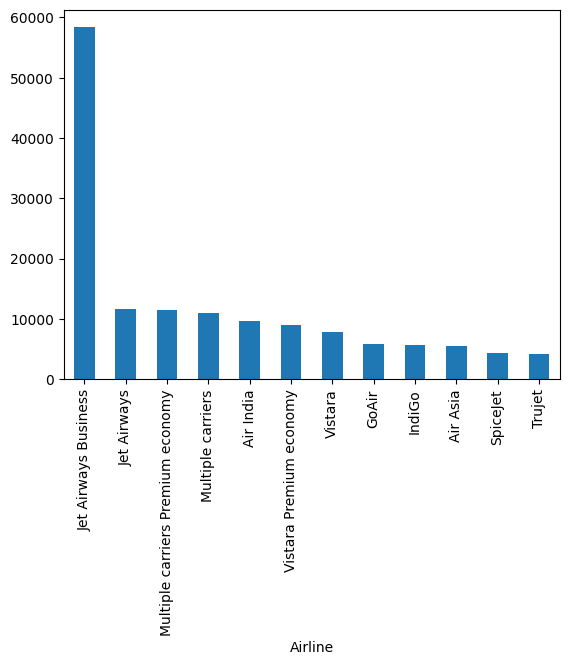

In [ ]:
df.groupby('Airline')['Price'].mean().sort_values(ascending=False).plot(kind='bar')

###Insight: Jet Airways has the highest Average Cost Per Flight. Since Jet Airways has business class only hence the average cost per flight is the max

###3.2)Average Ticket Price by Route (Source → Destination)

In [ ]:
df.groupby(['Source','Destination'])['Price'].mean().sort_values(ascending=False)

,,Price
Source,Destination,
Delhi,Cochin,10539.439057
Kolkata,Banglore,9158.389411
Banglore,Delhi,8017.464269
Mumbai,Hyderabad,5059.708752
Chennai,Kolkata,4789.892388


<Axes: xlabel='Source,Destination'>

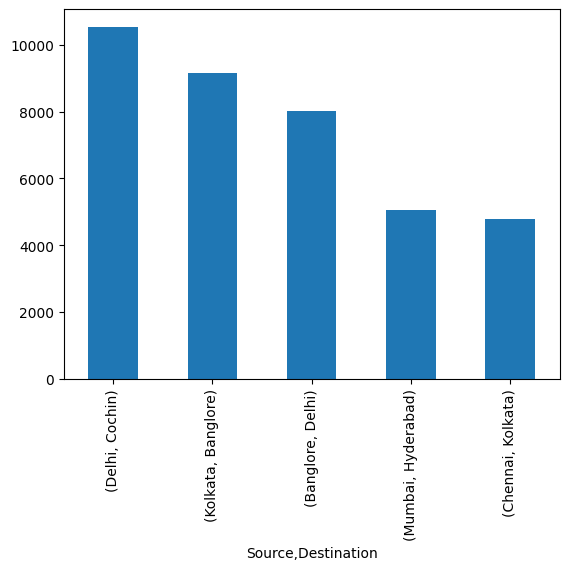

In [ ]:
df.groupby(['Source','Destination'])['Price'].mean().sort_values(ascending=False).plot(kind = 'bar')

###Insight: The route from Delhi to Cochin has the highest average ticket price.

###3.3)Average Price by Number of Stops

In [ ]:
df.groupby('Total_Stops')['Price'].mean().sort_values(ascending=False)

,Price
Total_Stops,
4,17686.000000
3,13112.000000
2,12715.807895
1,10593.570032
0,5024.900315


<Axes: xlabel='Total_Stops'>

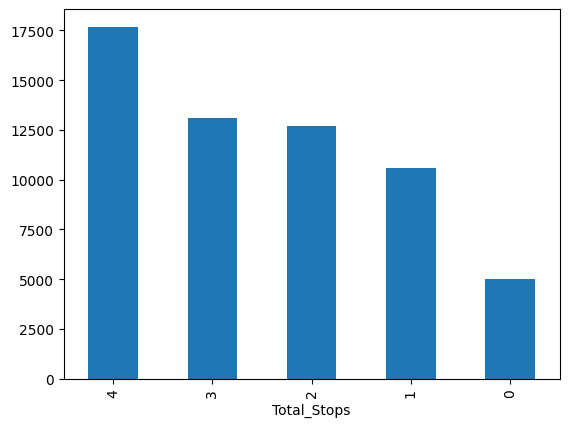

In [ ]:
df.groupby('Total_Stops')['Price'].mean().sort_values(ascending=False).plot(kind='bar')

###Insight: Flights with 4 stops have the highest average ticket price, and as the number of stops decreases, the average ticket price also tends to decrease, with non-stop flights having the lowest average price.

###3.4)Flight Volume by Airline

In [ ]:
df['Airline'].value_counts()
#other ways to to do this are
# 1) df.groupby('Airline').size()
# 2) df.groupby('Airline')['Airline'].count().sort_values(ascending=False)

,count
Airline,
Jet Airways,3849
IndiGo,2053
Air India,1752
Multiple carriers,1196
SpiceJet,818
Vistara,479
Air Asia,319
GoAir,194
Multiple carriers Premium economy,13


<Axes: xlabel='Airline'>

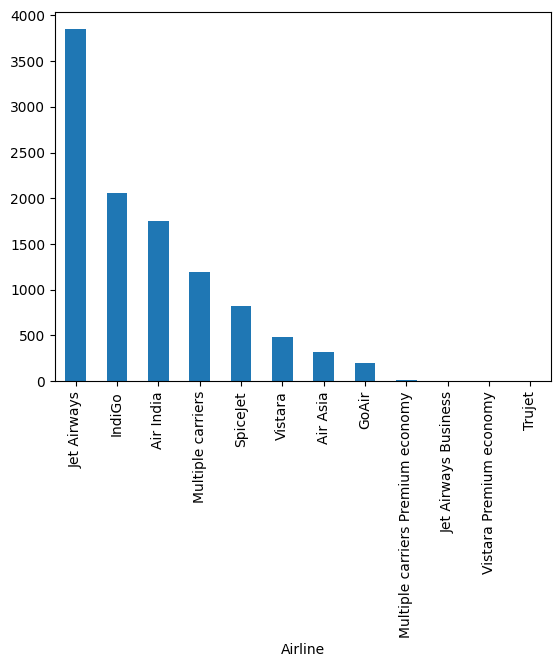

In [ ]:
df['Airline'].value_counts().plot(kind = 'bar')

###Insight: Jet Airways has the highest flight volume, indicating it operates the most flights among all airlines in the dataset, while Trujet has the lowest flight volume with only one flight.

###3.5)Flight Volume by Source Airport

In [ ]:
df.groupby('Source')['Airline'].value_counts()

Source    Airline                          
Banglore  Jet Airways                           788
          IndiGo                                523
          Air India                             332
          Vistara                               185
          SpiceJet                              181
          GoAir                                  93
          Air Asia                               89
          Jet Airways Business                    4
          Vistara Premium economy                 2
Chennai   IndiGo                                184
          SpiceJet                              128
          Vistara                                43
          Air India                              25
          Vistara Premium economy                 1
Delhi     Jet Airways                          1586
          Multiple carriers                    1196
          Air India                             747
          IndiGo                                705
          SpiceJet                               87
          Air Asia                               80
          GoAir                                  76
          Vistara                                45
          Multiple carriers Premium economy      13
          Jet Airways Business                    2
Kolkata   Jet Airways                          1256
          Air India                             512
          IndiGo                                445
          SpiceJet                              300
          Vistara                               183
          Air Asia                              150
          GoAir                                  25
Mumbai    Jet Airways                           219
          IndiGo                                196
          Air India                             136
          SpiceJet                              122
          Vistara                                23
          Trujet                                  1
Name: count, dtype: int64

<Axes: xlabel='Source'>

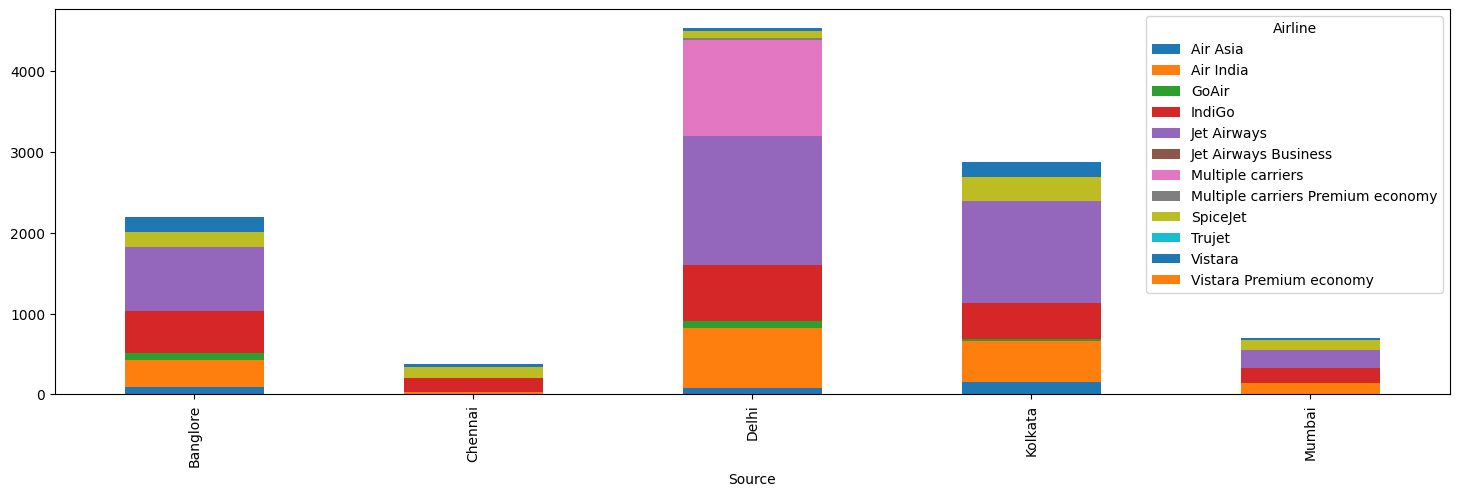

In [ ]:
df.groupby('Source')['Airline'].value_counts().unstack().plot(kind='bar',stacked = True, figsize = (18,5))

###Insight: Delhi is the busiest source airport, with Jet Airways operating the most flights from there. Conversely, Chennai has the lowest flight volume, where IndiGo is the primary carrier.

###3.6)Monthly Price Trend

In [ ]:
df.groupby('Month')['Price'].mean().sort_values(ascending=False)

,Price
Month,
3,10673.205580
5,9127.247548
6,8828.796134
4,5770.847081


<Axes: xlabel='Month'>

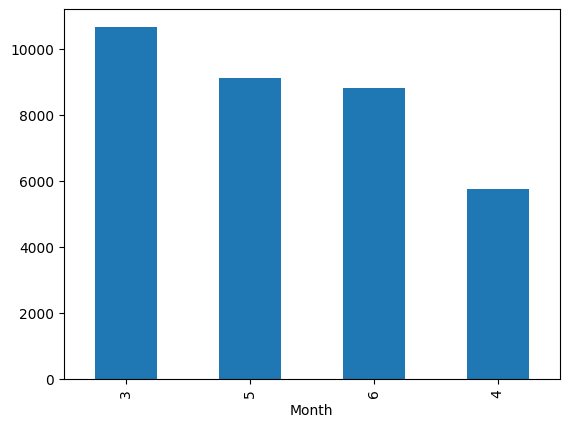

In [ ]:
df.groupby('Month')['Price'].mean().sort_values(ascending=False).plot(kind='bar')

###Insight: The monthly price trend indicates that March has the highest average ticket prices, while April shows the lowest, suggesting seasonal variations in flight costs where early spring flights are more expensive than mid-spring.

###3.7)Average Departure Hour by Airline

In [ ]:
df.groupby('Airline')['Dep_Hrs'].mean().round().sort_values(ascending=False)

,Dep_Hrs
Airline,
Air Asia,14.0
Vistara,13.0
Trujet,13.0
Jet Airways,13.0
IndiGo,12.0
GoAir,12.0
Air India,12.0
SpiceJet,12.0
Jet Airways Business,11.0


<Axes: xlabel='Airline'>

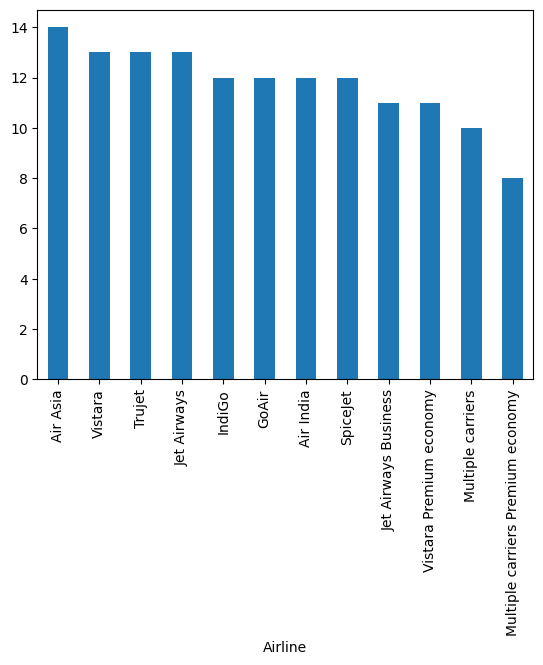

In [ ]:
df.groupby('Airline')['Dep_Hrs'].mean().round().sort_values(ascending=False).plot(kind='bar')

###Insight: Air Asia tends to have the latest average departure hour around 2 PM, while 'Multiple carriers Premium economy' flights generally depart earliest, averaging around 8 AM. Most other airlines have average departure hours concentrated around midday.


###3.8)Average Flight Duration by Airline

In [ ]:
df.groupby('Airline')['Duration_in_Mins'].mean().round().sort_values(ascending=False)

,Duration_in_Mins
Airline,
Air India,917.0
Jet Airways,823.0
Multiple carriers,603.0
Multiple carriers Premium economy,582.0
Vistara,567.0
Jet Airways Business,360.0
Air Asia,312.0
GoAir,262.0
IndiGo,253.0


<Axes: xlabel='Airline'>

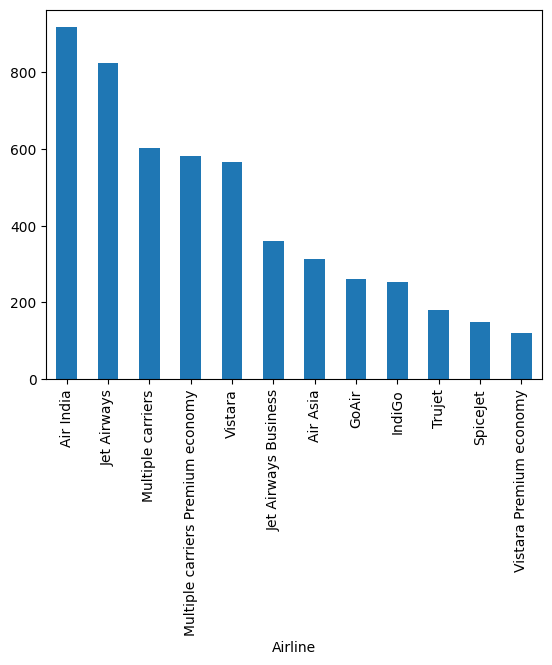

In [ ]:
df.groupby('Airline')['Duration_in_Mins'].mean().round().sort_values(ascending=False).plot(kind='bar')

###Insight: Air India and Jet Airways exhibit the longest average flight durations, likely due to their operation of more extensive long-haul and connecting routes. In contrast, airlines like SpiceJet and Vistara Premium economy have significantly shorter average flight durations, typically specializing in direct, shorter-haul domestic flights. This trend highlights the differing operational models and route networks among airlines.